# Statistical Inference

Notebooks 01–02 distinguished population properties from quantities calculated from a finite sample. Their simulations showed that one population can produce different estimates. This notebook asks how to assess that variation when the population parameter is unknown.

The focus is frequentist inference: statistical models and estimators, bias and consistency, sampling variance and MSE, then tests and confidence intervals. Maximum likelihood provides a common estimation framework, followed by asymptotic inference and model comparison. The Gaussian, Student-t and multivariate Gaussian distributions introduced earlier are examples of these parametric models.

Throughout the examples, $X_1,\ldots,X_n\overset{\mathrm{iid}}{\sim}F(\cdot;\theta)$ is a simplifying sampling framework. For returns, estimating model parameters also gives estimated expectations, dispersion, quantiles and tail means. These are estimates of population properties, rather than known future outcomes.

Notebook 04 describes the observations without choosing a parametric family. Later time-series notebooks introduce models that account for temporal dependence, which the IID framework does not capture.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})

from scipy.optimize import minimize
from finstats.inference import (bias, standard_error_mean,
    mean_confidence_interval,
    gaussian_loglikelihood)

## 1. Statistical Models and Inferential Problems

Inference connects an assumed population model with the finite observations used to estimate and test its unknown parameters.

### Statistical Models

**Definition: statistical model.** A statistical model is a family of probability distributions

$$
\mathcal P=\{F(\cdot;\theta):\theta\in\Theta\},
$$

where $\theta$ is the population parameter and $\Theta$ its parameter space. A parametric model uses a finite-dimensional $\theta$. For example, a Gaussian has $\theta=(\mu,\sigma^2)$ with $\sigma^2>0$, Student-t has location, positive scale and degrees of freedom, and a multivariate Gaussian has mean vector and covariance matrix.

### Random Samples, Estimators and Estimates

**Definition: random sample, estimator and estimate.** A random sample $X_1,\ldots,X_n\overset{\mathrm{iid}}{\sim}F(\cdot;\theta)$ has an unknown, fixed generating parameter. An estimator $\hat\theta_n=T(X_1,\ldots,X_n)$ is random because it is a function of that sample. Its observed value $T(x_1,\ldots,x_n)$ is an estimate. For example, $\bar X_n$ estimates $\mu$, while $\bar x_n$ is the realized estimate.

### Inferential Problems

Point estimation supplies a value, confidence intervals describe uncertainty, and hypothesis tests assess a specified claim about the parameter. Each answer depends on the assumed sampling model.

## 2. Bias, Variance and Mean-Squared Error

An estimator takes different values across samples from the same population. Bias describes its average error. Consistency concerns whether it concentrates around the population parameter as the sample grows. Variance describes its dispersion, and MSE combines dispersion with squared bias. These properties assess the estimation procedure, rather than one realized estimate.

### Bias

**Definition: bias.** The bias of an estimator is

$$
\operatorname{bias}(\hat\theta_n)=E[\hat\theta_n]-\theta.
$$

An estimator is unbiased when its expectation equals the population parameter. For iid observations with mean $\mu$, $E[\bar X_n]=\mu$. This statement concerns the sampling distribution, rather than equality between every realized sample mean and $\mu$.

### Consistency

**Definition: consistency.** An estimator is consistent when

$$
\hat\theta_n\xrightarrow{P}\theta,\qquad
\lim_{n\to\infty}P(|\hat\theta_n-\theta|\ge\varepsilon)=0\quad\text{for every }\varepsilon>0.
$$

Consistency describes concentration around the true parameter. It does not, by itself, imply that bias tends to zero. Convergence of expectations requires additional conditions. The sample mean is already unbiased at every sample size, while its consistency follows from the law of large numbers under IID sampling with a finite mean.

For illustration, I use the deliberately biased mean estimator

$$
\hat\mu_n=\frac{n}{n+1}\bar X_n,\qquad E[\hat\mu_n]=\frac{n}{n+1}\mu,\qquad
\operatorname{bias}(\hat\mu_n)=-\frac{\mu}{n+1}.
$$

The factor pulls estimates toward zero and tends to one, so the law of large numbers gives $\hat\mu_n\xrightarrow{P}\mu$. In this example, bias also tends to zero. This estimator is chosen to illustrate the distinction, rather than as a recommendation for estimating financial returns.

Under IID Gaussian sampling, the estimator has the exact sampling distribution

$$
\hat\mu_n\sim N\left(\frac{n}{n+1}\mu,\frac{n\sigma^2}{(n+1)^2}\right).
$$

For $N(5,4)$ observations, I compare this estimator with the sample mean,

$$
\bar X_n\sim N\left(\mu,\frac{\sigma^2}{n}\right).
$$

The figure has one row per sample size and two columns. Each row uses matching axes. The dashed line marks the true mean five, and the solid line marks the estimator's expectation. On the left these lines coincide at every sample size. On the right their separation is the finite-sample bias, labelled in each row. Both sampling distributions narrow around five as the sample grows. The common horizontal scale shows this concentration across rows, while density heights are matched within each row.

Unbiasedness concerns the expectation at a given sample size. Consistency concerns concentration around the true parameter as sample size grows. Both estimators here are consistent, but only the sample mean is unbiased at every sample size. The curves describe estimators across possible samples, rather than individual observations. Each density integrates to one.

For numerical comparison, I also draw 1000 independent samples at each size with seed 304. The table reports its average error and the fraction of estimates more than $.5$ from the true mean.

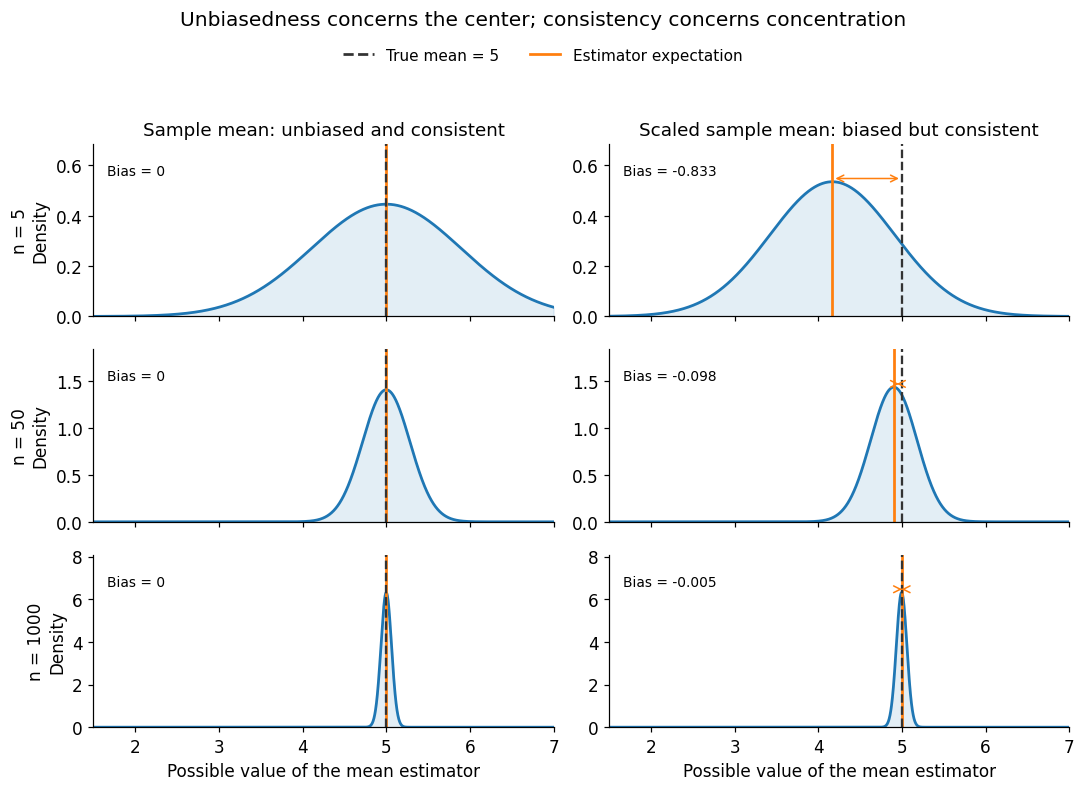

,n,Average estimate,MC bias,Fraction |error| > .5
0,5,4.1898,-0.8102,0.705
1,50,4.8971,-0.1029,0.094
2,1000,4.9941,-0.0059,0.000


In [2]:
rng_consistency = np.random.default_rng(304)
consistency_sizes, consistency_replications = (5, 50, 1000), 1000
consistency_rows = []
estimate_grid = np.linspace(1.5, 7, 4001)
fig, axes = plt.subplots(3, 2, figsize=(10, 7.2), sharex=True)
for row, sample_size in enumerate(consistency_sizes):
    factor = sample_size/(sample_size+1)
    sampling_mean = factor*5.
    mean_se = standard_error_mean(2., sample_size)
    sampling_se = factor*mean_se
    densities = (stats.norm.pdf(estimate_grid, 5., mean_se),
                 stats.norm.pdf(estimate_grid, sampling_mean, sampling_se))
    height = 1.28*max(density.max() for density in densities)
    for column, (ax, density, expectation) in enumerate(zip(axes[row], densities, (5., sampling_mean))):
        ax.plot(estimate_grid, density, color="C0")
        ax.fill_between(estimate_grid, density, color="C0", alpha=.12)
        ax.axvline(expectation, color="C1", linewidth=1.8)
        # Draw the dashed population line last so coincident lines remain visible.
        ax.axvline(5., color="0.2", linestyle="--", linewidth=1.5)
        ax.set(ylim=(0, height), xlim=(1.5, 7))
        if column == 0:
            ax.set_ylabel(f"n = {sample_size}\nDensity")
            ax.text(.03, .82, "Bias = 0", transform=ax.transAxes, fontsize=9)
        else:
            ax.text(.03, .82, f"Bias = {sampling_mean-5.:.3f}", transform=ax.transAxes, fontsize=9)
            ax.annotate("", xy=(sampling_mean, .8*height), xytext=(5., .8*height),
                        arrowprops={"arrowstyle": "<->", "color": "C1", "lw": 1})
    draws = rng_consistency.normal(5, 2, size=(consistency_replications, sample_size))
    means = np.array([sample_mean(sample) for sample in draws])
    estimates = factor*means
    consistency_rows.append([sample_size, sample_mean(estimates), bias(estimates, 5.),
                             np.mean(np.abs(estimates-5.) > .5)])
axes[0, 0].set_title("Sample mean: unbiased and consistent")
axes[0, 1].set_title("Scaled sample mean: biased but consistent")
for ax in axes[-1]:
    ax.set_xlabel("Possible value of the mean estimator")
from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([0], [0], color="0.2", linestyle="--", label="True mean = 5"),
                    Line2D([0], [0], color="C1", label="Estimator expectation")],
           loc="upper center", bbox_to_anchor=(.5, .965), ncol=2, fontsize=10)
fig.suptitle("Unbiasedness concerns the center; consistency concerns concentration", y=.995)
fig.tight_layout(rect=(0, 0, 1, .925), h_pad=1)
plt.show()
display(pd.DataFrame(consistency_rows, columns=["n", "Average estimate", "MC bias", "Fraction |error| > .5"])
        .round(4))


### Variance and Standard Error

**Definition: sampling variance and standard error.** The sampling variance describes dispersion of an estimator:

$$
\operatorname{Var}(\hat\theta)=E[(\hat\theta-E[\hat\theta])^2],\qquad
\mathrm{SE}(\hat\theta)=\sqrt{\operatorname{Var}(\hat\theta)}.
$$

For iid observations with finite variance,

$$
\operatorname{Var}(\bar X)=\sigma^2/n,\qquad \mathrm{SE}(\bar X)=\sigma/\sqrt n.
$$

The observation variance $\sigma^2$ and estimator variance $\sigma^2/n$ describe different objects. The realized sample variance $s^2$ estimates the former. The quantity $s/\sqrt n$ estimates the mean estimator's standard error.

### Mean-Squared Error

**Definition: mean-squared error.** Mean-squared error measures squared estimation error averaged over random samples:

$$
\operatorname{MSE}(\hat\theta_n)=E[(\hat\theta_n-\theta)^2]
=\operatorname{Var}(\hat\theta_n)+\operatorname{bias}(\hat\theta_n)^2.
$$

To obtain the decomposition, write the error as $(\hat\theta_n-E[\hat\theta_n])+(E[\hat\theta_n]-\theta)$. The cross term has expectation zero.

MSE combines dispersion and bias, so a smaller variance can compensate for some bias. Zero MSE requires both zero variance and zero bias. Unbiasedness alone does not imply zero MSE. For the sample mean, $\operatorname{MSE}(\bar X_n)=\sigma^2/n$.

MSE consistency means $\operatorname{MSE}(\hat\theta_n)\to0$. It implies consistency in probability, although the converse need not hold.

#### Model Complexity and Parsimony

When models estimate the same target, increasing flexibility can reduce approximation bias but increase the variability of the estimate across samples. The bias–variance decomposition helps explain why additional complexity may increase MSE even when bias falls. This trade-off motivates the **principle of parsimony**: additional model complexity should be justified by improved statistical accuracy, rather than by flexibility alone.

The figure is a schematic, not a simulation or a universal law. The chosen squared-bias curve falls with complexity, the variance curve rises, and their sum gives MSE. The lowest MSE occurs between the two extremes. Actual relationships depend on the model, estimator, sample size and target. For prediction of a noisy future observation, prediction MSE also includes irreducible noise. The figure concerns estimation MSE as defined above.

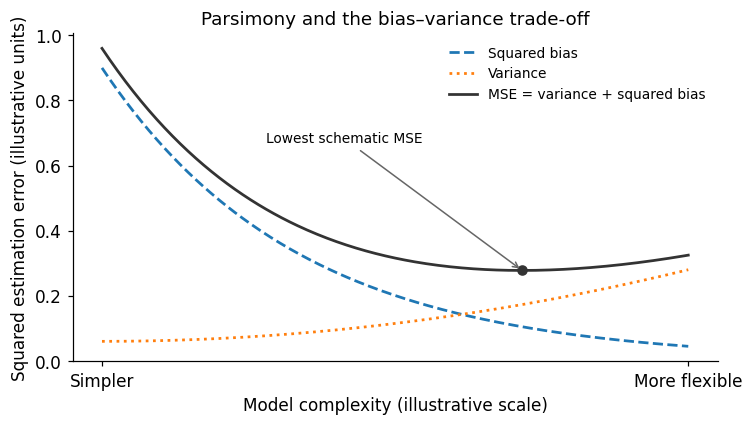

In [3]:
complexity = np.linspace(0, 1, 301)
# Illustrative curves, not estimates from data.
squared_bias = .9*np.exp(-3*complexity)
estimation_variance = .06+.22*complexity**2
schematic_mse = squared_bias+estimation_variance
minimum = np.argmin(schematic_mse)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(complexity, squared_bias, linestyle="--", label="Squared bias")
ax.plot(complexity, estimation_variance, linestyle=":", label="Variance")
ax.plot(complexity, schematic_mse, color="0.2", label="MSE = variance + squared bias")
ax.scatter(complexity[minimum], schematic_mse[minimum], color="0.2", s=35, zorder=3)
ax.annotate("Lowest schematic MSE", xy=(complexity[minimum], schematic_mse[minimum]),
            xytext=(.28, .67), arrowprops={"arrowstyle": "->", "color": "0.4"}, fontsize=9)
ax.set(xlabel="Model complexity (illustrative scale)", ylabel="Squared estimation error (illustrative units)",
       title="Parsimony and the bias–variance trade-off")
ax.set_xticks([0, 1], ["Simpler", "More flexible"])
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()
plt.show()


## 3. Statistical Inference — Frequentist

Estimation supplies a value for an unknown population parameter. Frequentist inference assesses a claim about that parameter or constructs a set of plausible values using the sampling model. The framework below applies beyond Gaussian distributions. Its exact or approximate calibration depends on the assumptions of the particular model.

### Hypotheses and Inferential Questions

**Definition: null and alternative hypotheses.** A null hypothesis is compared with an alternative:

$$
H_0:\theta\in\Theta_0,\qquad H_1:\theta\in\Theta_1.
$$

The population parameter is fixed but unknown. A simple null specifies one parameter value, while a composite null specifies a set. The alternative determines whether departures in one direction or both directions matter.

Type I error means rejecting a true null. Type II error means failing to reject a false null. A test aims to control the first while retaining the ability to detect relevant alternatives. Failing to reject does not establish that the null is true.

### Population and Sampling Distributions

Notebooks 01–02 described population distributions of observations and finite-sample quantities calculated from them. Under $X_1,\ldots,X_n\overset{\mathrm{iid}}{\sim}F(\cdot;\theta)$, $F$ describes individual observations. A statistic

$$
T_n=T(X_1,\ldots,X_n)
$$

has its own distribution across possible samples, called its sampling distribution.

The sampling distribution depends on the model, sample size and statistic. Its dispersion is different from the dispersion of individual observations. For a test, the relevant reference is the statistic's sampling distribution **under the null hypothesis**. It may be available exactly or approximated asymptotically. Unknown nuisance parameters may need to be accounted for before that reference distribution can be used.

### Test Statistics and Critical Regions

**Definition: test statistic.** A test statistic summarizes the departure of the sample from the null. Its realized value is

$$
t_{\mathrm{obs}}=T(x_1,\ldots,x_n).
$$

A critical region $C_\alpha$ specifies the values leading to rejection. The significance level controls Type I error:

$$
\sup_{\theta\in\Theta_0}P_\theta(T_n\in C_\alpha)\le\alpha.
$$

This is an exact requirement for a level-$\alpha$ test. An asymptotic test has the corresponding large-sample calibration, which need not hold exactly at finite $n$. For $\theta\in\Theta_1$, power is $P_\theta(T_n\in C_\alpha)$ and Type II error probability is one minus power.

A p-value summarizes how extreme the observed statistic is relative to its null reference distribution. Once an ordering of extremeness and a valid null calibration have been specified, it can be viewed as the smallest significance level at which the corresponding test rejects. It is not the probability that $H_0$ is true. The direction of the alternative determines which tail or tails enter the calculation.

### Confidence Intervals

**Definition: confidence interval.** A confidence interval has random endpoints calculated from the sample:

$$
C_n=[L_n,U_n],\qquad P_\theta(\theta\in C_n)\ge1-\alpha.
$$

An exact equal-coverage procedure has equality. An asymptotic procedure approaches its nominal coverage under the required conditions. The parameter is fixed. Repeated sampling generates intervals that cover it at the procedure's stated rate. Once observed, $c_n=[l_n,u_n]$ is fixed and either contains the parameter or does not.

Intervals and tests are connected. Inverting a family of level-$\alpha$ tests gives the confidence set of parameter values not rejected:

$$
C_n=\{\theta_0:H_0:\theta=\theta_0\text{ is not rejected by its corresponding test}\}.
$$

For a matching two-sided test and confidence interval, rejection occurs when the null value lies outside the interval. This connection concerns corresponding procedures, rather than arbitrary tests and intervals.

### Example: Gaussian Inference for Mean and Standard Deviation

Assume IID $N(\mu,\sigma^2)$ observations, with both parameters unknown. I simulate ten observations from $N(5,4)$ with seed 314 and conduct two separate two-sided tests at the 5% level. The null values are $\mu_0=5$ and $\sigma_0=2$.

For the mean, estimate dispersion using the adjusted sample variance $S_n^2$:

$$
H_0:\mu=\mu_0,\qquad H_1:\mu\ne\mu_0,
$$

$$
T_n=\frac{\bar X_n-\mu_0}{S_n/\sqrt n}\sim t_{n-1}\quad\text{under }H_0.
$$

Reject when $|T_n|>t_{1-\alpha/2,n-1}$. For standard deviation, the equivalent variance test uses

$$
H_0:\sigma=\sigma_0,\qquad H_1:\sigma\ne\sigma_0,
$$

$$
Q_n=\frac{(n-1)S_n^2}{\sigma_0^2}\sim\chi^2_{n-1}\quad\text{under }H_0.
$$

Reject when $Q_n<\chi^2_{\alpha/2,n-1}$ or $Q_n>\chi^2_{1-\alpha/2,n-1}$. Both reference distributions are exact under IID Gaussian sampling. For this equal-tail variance test, the p-value is twice the smaller null tail probability, capped at one.

The panels show each null density, its rejection regions and the observed statistic. The mean test does not reject, while the standard-deviation test rejects. Both null values equal the simulated population parameters, so the latter is a Type I error in this realization. A 5% test permits occasional false rejection. These are separate tests, each at 5%, rather than a joint test of both parameters. Section 4 reuses the same sample for Gaussian MLE.

,Parameter,Null value,Estimate,Statistic,Two-sided p-value,Reject at 5%
0,Mean μ,5.0,5.0609,0.2112,0.8374,False
1,Standard deviation σ,2.0,0.9118,1.8706,0.0133,True


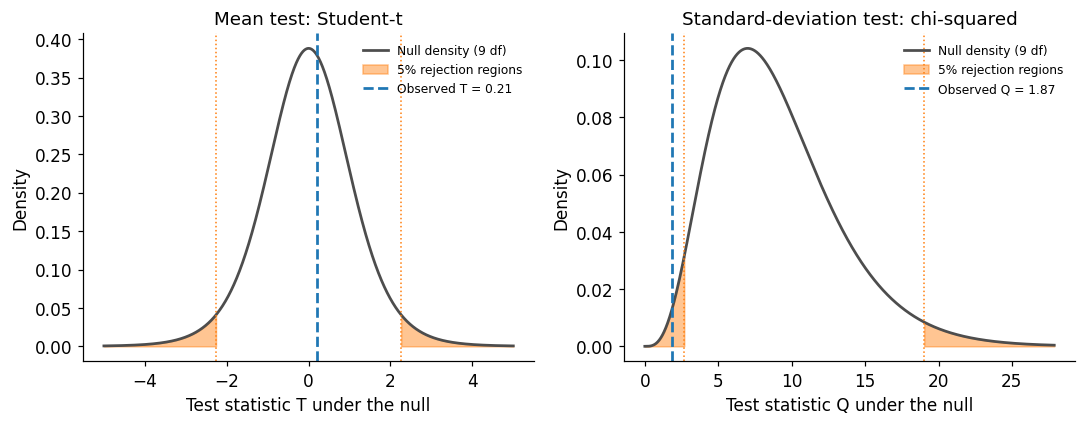

In [4]:
alpha, null_mean, null_sigma = .05, 5., 2.
likelihood_sample = np.random.default_rng(314).normal(5, 2, size=10)
sample_size = likelihood_sample.size
degrees_of_freedom = sample_size-1
observed_mean = sample_mean(likelihood_sample)
observed_variance = sample_variance(likelihood_sample)
observed_sigma = sample_standard_deviation(likelihood_sample)
observed_se = standard_error_mean(observed_sigma, sample_size)
t_observed = (observed_mean-null_mean)/observed_se
t_critical = stats.t.ppf(1-alpha/2, degrees_of_freedom)
mean_p_value = 2*stats.t.sf(abs(t_observed), degrees_of_freedom)
q_observed = degrees_of_freedom*observed_variance/null_sigma**2
q_lower, q_upper = stats.chi2.ppf([alpha/2, 1-alpha/2], degrees_of_freedom)
sigma_p_value = min(1., 2*min(stats.chi2.cdf(q_observed, degrees_of_freedom),
                            stats.chi2.sf(q_observed, degrees_of_freedom)))
display(pd.DataFrame({"Parameter": ["Mean μ", "Standard deviation σ"],
                      "Null value": [null_mean, null_sigma],
                      "Estimate": [observed_mean, observed_sigma],
                      "Statistic": [t_observed, q_observed],
                      "Two-sided p-value": [mean_p_value, sigma_p_value],
                      "Reject at 5%": [abs(t_observed) > t_critical,
                                       q_observed < q_lower or q_observed > q_upper]}).round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
t_grid = np.linspace(-5, 5, 1601)
q_grid = np.linspace(0, stats.chi2.ppf(.999, degrees_of_freedom), 1601)
plot_cases = (
    (axes[0], t_grid, stats.t(degrees_of_freedom), (-t_critical, t_critical), t_observed,
     "Mean test: Student-t", "T", "Mean: do not reject"),
    (axes[1], q_grid, stats.chi2(degrees_of_freedom), (q_lower, q_upper), q_observed,
     "Standard-deviation test: chi-squared", "Q", "Standard deviation: reject"),
)
for ax, grid, reference, boundaries, observed, title, symbol, conclusion in plot_cases:
    density = reference.pdf(grid)
    ax.plot(grid, density, color="0.3", label=f"Null density ({degrees_of_freedom} df)")
    for side, boundary in enumerate(boundaries):
        condition = grid <= boundary if side == 0 else grid >= boundary
        ax.fill_between(grid, density, where=condition, color="C1", alpha=.45,
                        label="5% rejection regions" if side == 0 else None)
        ax.axvline(boundary, color="C1", linestyle=":", linewidth=1)
    ax.axvline(observed, color="C0", linestyle="--", label=f"Observed {symbol} = {observed:.2f}")
    ax.set(xlabel=f"Test statistic {symbol} under the null", ylabel="Density", title=title)
    ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()


## 4. Maximum Likelihood Estimation

The preceding intervals and tests used Gaussian sampling results. Likelihood provides a common estimation framework for Gaussian and other parametric models. Estimation and the calibration of inferential uncertainty remain separate steps.

### Likelihood and Log-Likelihood

**Definition: likelihood and log-likelihood.** Let $Y_1,\ldots,Y_n$ be iid with density or mass function $f(y;\theta)$. For observed values $y_1,\ldots,y_n$, the likelihood is the joint density or mass viewed as a function of $\theta$:

$$
L(\theta;y)=\prod_{i=1}^n f(y_i;\theta),\qquad
\ell(\theta;y)=\sum_{i=1}^n\log f(y_i;\theta).
$$

The sample is fixed when comparing parameter values. A likelihood is not a probability distribution over parameters.

In practice, estimation often uses the **log-likelihood** because it is easier to work with. It turns the product of individual densities into a sum, which simplifies differentiation and computation. Adding log-densities also avoids multiplying many small numbers that can cause numerical underflow. Since the logarithm is strictly increasing, likelihood and log-likelihood have the same maximizing parameter.

### Maximizing the Likelihood

**Definition: maximum likelihood estimate.** The estimate maximizes likelihood for the observed sample:

$$
\hat\theta_{ML}(y)=\operatorname*{arg\,max}_{\theta\in\Theta}L(\theta;y)
=\operatorname*{arg\,max}_{\theta\in\Theta}\ell(\theta;y).
$$

Before observing the sample, $\hat\theta_{ML}(Y)$ is an estimator and therefore a random variable.

### Closed-Form Solutions

A closed-form solution expresses the maximizing parameter directly as a function of the observations. It follows from solving the likelihood equations analytically, rather than searching numerically. Some parametric models admit such a solution.

Below, I consider IID Gaussian observations with unknown mean $\mu$ and **known variance** $\sigma^2$. For the observed sample,

$$
\ell(\mu)=-\frac n2\log(2\pi\sigma^2)-\frac1{2\sigma^2}\sum_i(x_i-\mu)^2.
$$

The first-order condition gives

$$
\frac{\partial\ell}{\partial\mu}=\frac1{\sigma^2}\sum_i(x_i-\mu)=0
\quad\Longrightarrow\quad \hat\mu_{ML}=\bar x_n.
$$

The second derivative is negative everywhere,

$$
\frac{\partial^2\ell}{\partial\mu^2}=-\frac n{\sigma^2}<0,
$$

so the sample mean is the unique global maximum.

I reuse the size-ten $N(5,4)$ sample from Section 3, now treating variance four as known rather than estimated. The left panel shows log-likelihood and the right shows likelihood, $L(\mu)=\exp[\ell(\mu)]$, for the same candidate means and fixed variance. Both peak at $\hat\mu_{ML}=\bar x_n$, since taking the logarithm preserves the maximizing value. The generating mean five is marked separately from its realized estimate.

,Population mean,Realized mean MLE,Known variance
0,5.0,5.0609,4.0


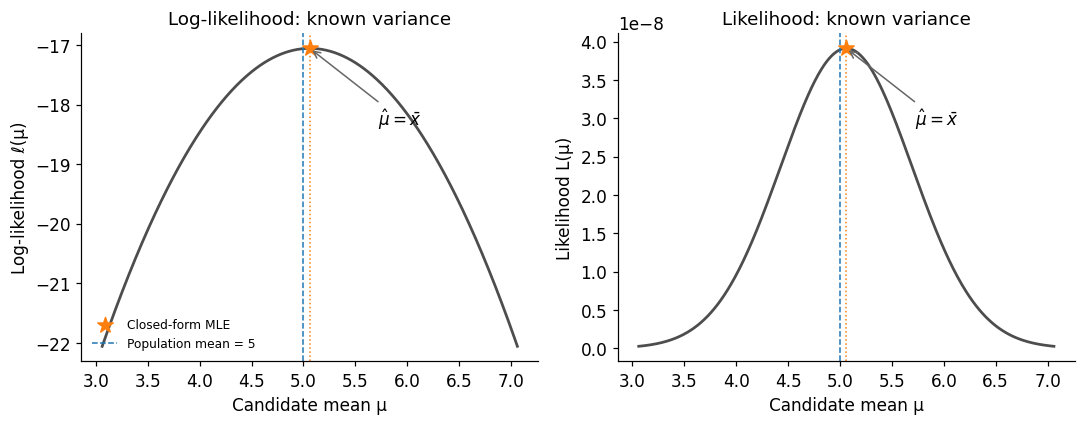

In [5]:
known_variance = 4.
mu_mle = sample_mean(likelihood_sample)
display(pd.DataFrame({"Population mean": [5.], "Realized mean MLE": [mu_mle],
                      "Known variance": [known_variance]}).round(4))
mean_grid = np.sort(np.append(np.linspace(mu_mle-2., mu_mle+2., 501), mu_mle))
mean_loglikelihood = np.array([gaussian_loglikelihood((mean, known_variance), likelihood_sample)
                              for mean in mean_grid])
mean_likelihood = np.exp(mean_loglikelihood)
maximum_loglikelihood = gaussian_loglikelihood((mu_mle, known_variance), likelihood_sample)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
for ax, values, peak, title, ylabel in (
    (axes[0], mean_loglikelihood, maximum_loglikelihood, "Log-likelihood: known variance", "Log-likelihood ℓ(μ)"),
    (axes[1], mean_likelihood, np.exp(maximum_loglikelihood), "Likelihood: known variance", "Likelihood L(μ)"),
):
    ax.plot(mean_grid, values, color="0.3")
    ax.axvline(mu_mle, color="C1", linestyle=":", linewidth=1)
    ax.scatter(mu_mle, peak, color="C1", marker="*", s=110, label="Closed-form MLE", zorder=3)
    ax.axvline(5., color="C0", linestyle="--", linewidth=1, label="Population mean = 5")
    ax.annotate(r"$\hat\mu=\bar x$", xy=(mu_mle, peak), xytext=(.65, .72), textcoords="axes fraction",
                arrowprops={"arrowstyle": "->", "color": "0.4"}, fontsize=11)
    ax.set(xlabel="Candidate mean μ", ylabel=ylabel, title=title)
axes[1].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axes[0].legend(fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()


### Numerical Solutions

When a closed-form solution is unavailable, numerical optimization searches for a maximizer of the log-likelihood. Student-t and skew-normal parameters generally require this approach. Starting values can affect the result, and numerical convergence alone does not establish a global maximum. A lower local maximum can satisfy the optimizer's stopping rule.

For illustration, I estimate location from four IID $t_3(0,1)$ observations, holding scale one and degrees of freedom three fixed. Seed 515 was deliberately selected to produce a separated observation and two local maxima. This small sample demonstrates a possible difficulty, not a typical outcome or a comparison of optimization methods. The observations are approximately $(-1.20,-14.20,2.97,-1.01)$.

For this fixed-scale model,

$$
\ell(\mu)=C-\frac{\nu+1}{2}\sum_i\log\left[1+\frac{(x_i-\mu)^2}{\nu}\right],
$$

where $C$ is constant in $\mu$. The curve shows the objective actually optimized. Crosses mark starting values, circles mark converged solutions, and arrows connect the two. One start reaches the lower local maximum, while the others reach the higher maximum. Comparing solutions and their likelihood values helps detect this failure. Agreement between several starts alone would still not prove global optimality.

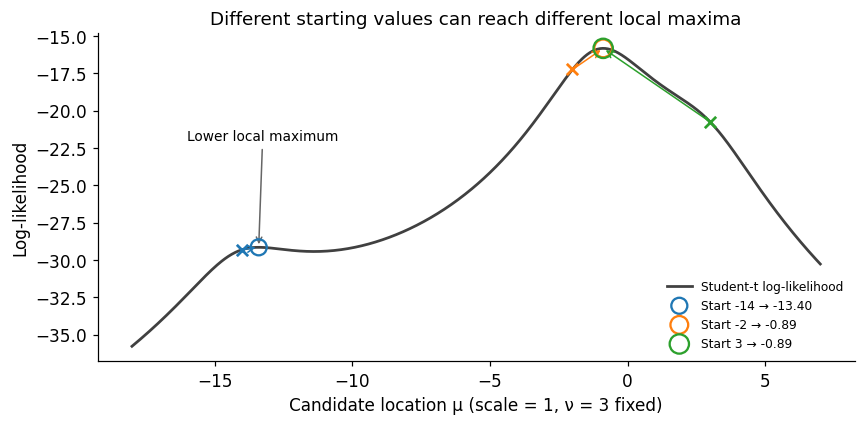

,Starting location,Converged location,Converged,Log-likelihood
0,-14.0,-13.397143,True,-29.154506
1,-2.0,-0.885151,True,-15.839934
2,3.0,-0.885146,True,-15.839934


In [6]:
numerical_sample = np.random.default_rng(515).standard_t(3, size=4)
starts = (-14., -2., 3.)
def location_loglikelihood(location):
    return stats.t.logpdf(numerical_sample, 3, loc=location).sum()
results = [minimize(lambda p: -location_loglikelihood(p[0]), [start], method="BFGS")
           for start in starts]
location_grid = np.linspace(-18, 7, 801)
loglikelihood_curve = np.array([location_loglikelihood(m) for m in location_grid])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(location_grid, loglikelihood_curve, color="0.25", label="Student-t log-likelihood")
for j, (start, result) in enumerate(zip(starts, results)):
    start_height, end_height = location_loglikelihood(start), -result.fun
    ax.scatter(start, start_height, marker="x", color=f"C{j}", s=55, zorder=3)
    ax.scatter(result.x[0], end_height, marker="o", facecolors="none", edgecolors=f"C{j}",
               s=110+25*j, linewidth=1.5, label=f"Start {start:g} → {result.x[0]:.2f}", zorder=4)
    ax.annotate("", xy=(result.x[0], end_height), xytext=(start, start_height),
                arrowprops={"arrowstyle": "->", "color": f"C{j}", "lw": 1})
ax.annotate("Lower local maximum", xy=(results[0].x[0], -results[0].fun),
            xytext=(-16, -22), arrowprops={"arrowstyle": "->", "color": "0.4"}, fontsize=9)
ax.set(xlabel="Candidate location μ (scale = 1, ν = 3 fixed)", ylabel="Log-likelihood",
       title="Different starting values can reach different local maxima")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()
display(pd.DataFrame({"Starting location": starts, "Converged location": [r.x[0] for r in results],
                      "Converged": [r.success for r in results], "Log-likelihood": [-r.fun for r in results]}))


### Asymptotics and Inference under MLE

MLE itself does not require asymptotic theory. Its standard errors, intervals and tests often use large-sample approximations.

**Asymptotic normality.** Under regularity conditions,

$$
\sqrt n(\hat\theta_{ML}-\theta)\xrightarrow{d}N(0,V(\theta)).
$$

This requires an identifiable model, an interior parameter and suitable smoothness and moment conditions. The approximate covariance of the unscaled estimator is $V(\theta)/n$.

**Standard errors.** Fitting software may provide an estimated parameter covariance matrix. Standard errors are the square roots of its diagonal entries. A reported covariance for the unscaled estimator already incorporates sample-size scaling.

**Inference.** For a scalar parameter, the approximate Wald interval is

$$
\hat\theta_{ML}\pm z_{1-\alpha/2}\widehat{SE}(\hat\theta_{ML}).
$$

For a two-sided test,

$$
H_0:\theta=\theta_0,\qquad H_1:\theta\ne\theta_0,
$$

$$
Z_W=\frac{\hat\theta_{ML}-\theta_0}{\widehat{SE}(\hat\theta_{ML})}\approx N(0,1)\quad\text{under }H_0.
$$

Reject when $|Z_W|>z_{1-\alpha/2}$. This calibration is asymptotic, unlike the exact Gaussian tests in Section 3. Its finite-sample accuracy depends on the model and sample size.

### Comparing Models: AIC and BIC

Different parametric models can describe the same observations. Gaussian and Laplace models each have two estimated parameters, while a Student-t model with estimated location, scale and degrees of freedom has three. Their maximized log-likelihoods measure fit to the observed sample.

For nested models, adding free parameters cannot lower the maximized likelihood, because the larger model includes the smaller one. Improved sample fit alone therefore does not justify greater complexity. This connects to the principle of parsimony introduced in Section 2.

The **Akaike Information Criterion (AIC)** and **Bayesian Information Criterion (BIC)** balance likelihood fit with a penalty for the number of estimated parameters:

$$
\mathrm{AIC}=-2\ell(\hat\theta_{ML})+2p,
$$

$$
\mathrm{BIC}=-2\ell(\hat\theta_{ML})+p\log n.
$$

Here $p$ counts free parameters estimated from the data, including scale or variance, and $n$ is the sample size. Parameters fixed in advance are not counted. The logarithm is natural. Lower values are preferred within the candidate set. For $n>e^2$, BIC imposes a larger penalty per additional parameter than AIC.

As a numerical illustration, suppose two models fitted to the same 100 observations give the following maximized log-likelihoods. These numbers illustrate the arithmetic rather than results from another simulation.

| Model | Estimated parameters $p$ | Maximized log-likelihood | AIC | BIC |
| --- | ---: | ---: | ---: | ---: |
| A | 2 | −100.0 | 204.0 | 209.21 |
| B | 3 | −98.8 | 203.6 | 211.42 |

Model B improves sample fit enough for AIC to prefer it, while BIC's larger penalty favors A. The criteria can therefore disagree. They compare penalized likelihoods, rather than directly calculating estimator MSE.

Compare models fitted to the **same observations**, with consistent likelihood definitions, units and retained constants. The models need not be nested. A lower criterion is relative evidence within the candidate set, not a goodness-of-fit test or proof that the selected model is the true DGP. The comparison also depends on obtaining reliable likelihood maxima, which connects back to starting-value sensitivity above.

Notebook 04 returns to the observations themselves. Histograms, density estimates and empirical quantiles provide descriptions that can then be compared with candidate parametric models.